# Notebook 01 — Exploración del Corpus

**Curso:** Minería de Textos | **Proyecto 3** | CUC
**Línea:** B — Emoción / Sentimiento

---

## Objetivo
Conectar a MongoDB Atlas, cargar el corpus de canciones y obtener estadísticas detalladas para verificar la calidad de los datos antes de construir el pipeline RAG.


In [1]:
# Instalación de dependencias (solo la primera vez)
!pip install -q pymongo[srv] python-dotenv pandas matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys
sys.path.append('../app')
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from app.config import DB_NAME, COLLECTION_NAME
from src.mongo_utils import mongo_utils

print('Librerías cargadas.')

Librerías cargadas.


## 1. Verificar conexión a MongoDB Atlas

In [2]:
db_conexion = mongo_utils()
if db_conexion.verificar_conexion():
    print(f'Base de datos: {DB_NAME} | Colección: {COLLECTION_NAME}')


2026-04-19 21:38:20 | INFO     | MongoDBManager | Conectando a MongoDB Atlas | DB: analisisMusical | Col: analisisMusical
2026-04-19 21:38:21 | INFO     | MongoDBManager | Conexión verificada correctamente.
Base de datos: analisisMusical | Colección: analisisMusical


## 2. Estadísticas del corpus

In [3]:
stats = db_conexion.estadisticas_corpus()

print('RESUMEN DEL CORPUS')
print('=' * 50)
print(f"Total documentos:  {stats['total_documentos']}")
print(f"Con letra:         {stats['con_letra']}")
print(f"Sin letra:         {stats['total_documentos'] - stats['con_letra']}")
print(f"Rango de años:     {stats['anio_min']} — {stats['anio_max']}")
print(f"\nGéneros:")
for g, c in sorted(stats['generos'].items(), key=lambda x: -x[1]):
    print(f'  {g:20s}: {c}')
print(f"\nIdiomas:")
for i, c in sorted(stats['idiomas'].items(), key=lambda x: -x[1]):
    print(f'  {i:10s}: {c}')

2026-04-19 21:38:24 | INFO     | MongoDBManager | Calculando estadísticas del corpus...
2026-04-19 21:38:25 | INFO     | MongoDBManager | Estadísticas listas | Géneros: 63 | Idiomas: 30
RESUMEN DEL CORPUS
Total documentos:  6940
Con letra:         6940
Sin letra:         0
Rango de años:     1990 — 2025

Géneros:
  pop                 : 3350
  hip hop             : 1910
  alternative rock    : 282
  k pop               : 263
  dance pop           : 217
  alternative pop     : 157
  reggaeton           : 152
  country             : 95
  rb                  : 94
  trap                : 63
  latin               : 55
  rock                : 39
  thrash metal        : 32
  electronic          : 31
  bachata             : 27
  salsa               : 25
  folk rock           : 22
  pop rap             : 21
  jazz                : 13
  rap                 : 12
  pop rock            : 6
  latin pop           : 6
  rap hip hop         : 5
  contemporary rb     : 5
  synth pop           : 4
  pop 

## 3. Cargar muestra para análisis detallado

In [4]:
canciones = db_conexion.cargar_canciones()

# Convertir a DataFrame
df = pd.DataFrame([{
    'titulo':  c.get('titulo', ''),
    'artista': c.get('artista', ''),
    'genero':  c.get('genero', ''),
    'anio':    c.get('anio'),
    'idioma':  c.get('idioma', ''),
    'len_letra': len(str(c.get('letra', ''))),
} for c in canciones])

print(f'DataFrame: {df.shape}')
df.head()

2026-04-19 21:38:28 | INFO     | MongoDBManager | Cargando canciones | limite=None | solo_con_letra=True
2026-04-19 21:38:32 | INFO     | MongoDBManager | Canciones cargadas: 6940
DataFrame: (6940, 6)


,titulo,artista,genero,anio,idioma,len_letra
0,"​thank u, next",Ariana Grande,pop,2018,en,2290
1,7 rings,Ariana Grande,pop,2019,en,2172
2,​God is a woman,Ariana Grande,pop,2018,en,1963
3,Side To Side,Ariana Grande,pop,2016,en,2703
4,​​no tears left to cry,Ariana Grande,pop,2018,en,2290


In [5]:
print('CALIDAD DE DATOS')
print('=' * 40)
print('NULOS DE DATOS')
print('=' * 40)
print(df.isnull().sum())
print(f"\nLetras vacías (<50 chars): {(df['len_letra'] < 50).sum()}")
print(f"Duplicados (título+artista): {df.duplicated(subset=['titulo', 'artista']).sum()}")
print(f"\nLongitud promedio de letra: {df['len_letra'].mean():.0f} chars")
print(f"Longitud mínima:            {df['len_letra'].min()}")
print(f"Longitud máxima:            {df['len_letra'].max()}")

CALIDAD DE DATOS
NULOS DE DATOS
titulo       0
artista      0
genero       0
anio         0
idioma       0
len_letra    0
dtype: int64

Letras vacías (<50 chars): 0
Duplicados (título+artista): 406

Longitud promedio de letra: 2102 chars
Longitud mínima:            92
Longitud máxima:            29720


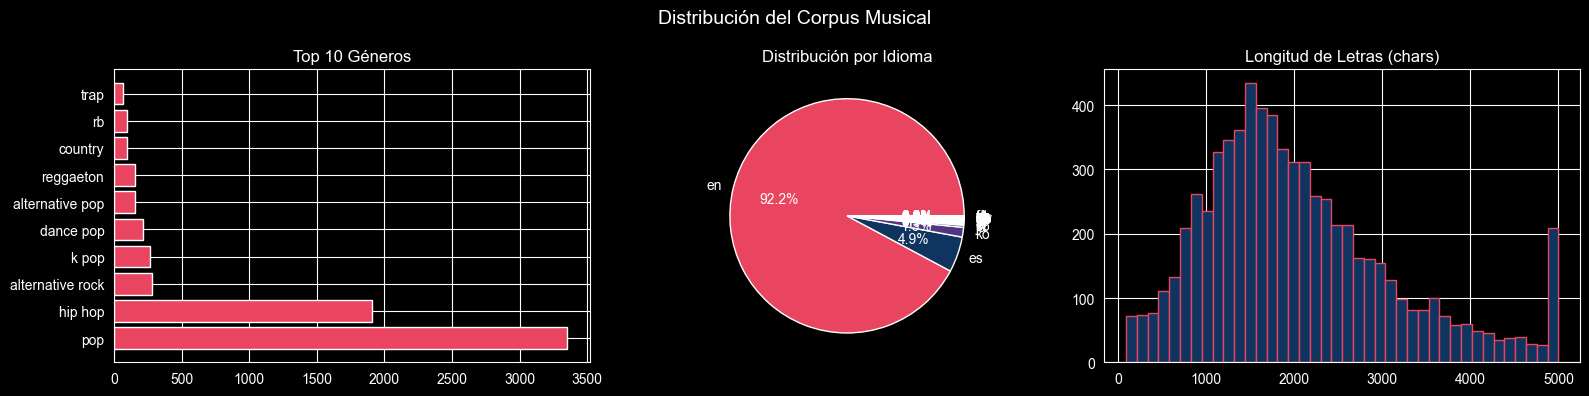

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución del Corpus Musical', color='white', fontsize=14)

# Géneros
generos = df['genero'].value_counts().head(10)
axes[0].barh(generos.index, generos.values, color='#e94560')
axes[0].set_title('Top 10 Géneros', color='white')
axes[0].tick_params(colors='white')

# Idiomas
idiomas = df['idioma'].value_counts()
axes[1].pie(idiomas.values, labels=idiomas.index, autopct='%1.1f%%',
            colors=['#e94560', '#0f3460', '#533483', '#16213e', '#1a1a2e'])
axes[1].set_title('Distribución por Idioma', color='white')

# Longitud de letras
axes[2].hist(df['len_letra'].clip(upper=5000), bins=40, color='#0f3460', edgecolor='#e94560')
axes[2].set_title('Longitud de Letras (chars)', color='white')
axes[2].tick_params(colors='white')

plt.tight_layout()
plt.show()